# Machine Learning on the `spy` ETF

[*********************100%***********************]  1 of 1 completed


<Figure size 1200x600 with 0 Axes>

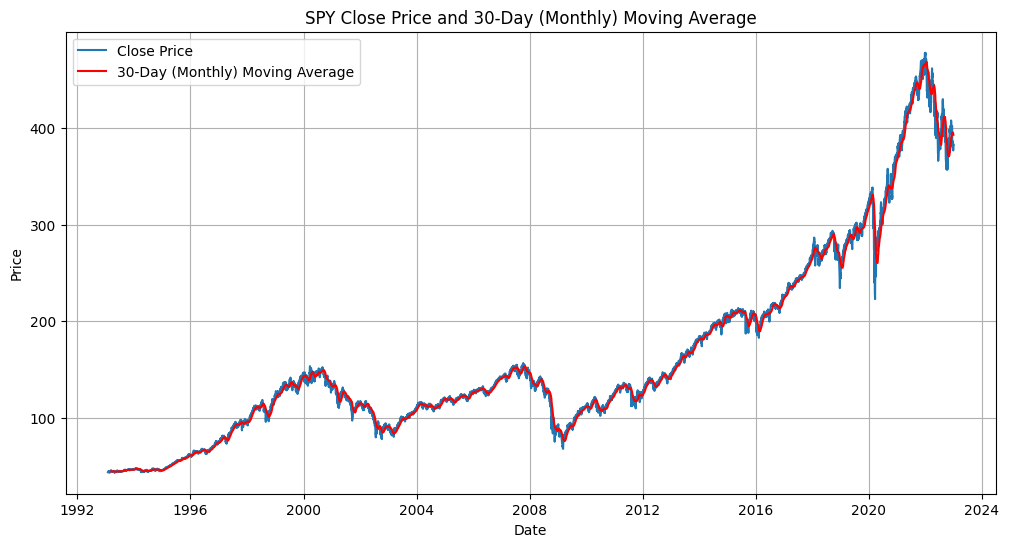

<Figure size 1200x600 with 0 Axes>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Load the data
spy = yf.download('SPY', start='1993-01-01', end='2023-01-01')

# Calculate the moving average
spy['MA'] = spy['Close'].rolling(window=30).mean()

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(spy['Close'], label='Close Price')
plt.plot(spy['MA'], label='30-Day (Monthly) Moving Average', color='red')
plt.title('SPY Close Price and 30-Day (Monthly) Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.figure(figsize=(12, 6))


## Key Terms:

SPDR S&P 500 ETF Trust:
- An exchange-traded fund (ETF) that aims to track the performance of the S&P 500 index.
- ETF: A type of investment fund traded on stock exchanges, similar to stocks.

NYSE Arca:
- An electronic securities exchange where the SPDR S&P 500 ETF (SPY) is traded.

SPY:
- The ticker symbol for the SPDR S&P 500 ETF on the NYSE Arca.

SPDR:
- Acronym for Standard & Poor's Depositary Receipts.
- Now a trademark of Standard & Poor's Financial Services LLC.

S&P 500:
- A stock market index of 500 large companies listed on U.S. stock exchanges.

CUSIP (78462F103):
- Committee on Uniform Securities Identification Procedures.
- A unique identifier for financial instruments in the U.S. and Canada.

ISIN (US78462F1030):
- International Securities Identification Number.
- A global standard for identifying specific securities.

Net Expense Ratio (0.0945%):
- The annual fee charged to shareholders for operating the fund.

State Street Global Advisors (SSGA):
- The asset management company that launched SPY.

Assets Under Management (AUM):
- The total market value of assets that an investment company manages on behalf of investors.
- SPY reached $500 billion in AUM in February 2024, a significant milestone.

Competing ETFs:
- Vanguard S&P 500 ETF (VOO) and iShares S&P 500 Index (IVV) are major competitors to SPY.

Performance Metrics:
- 1-Year Return: The fund's performance over the past year.
- 5-Year Average Annual Return: The average yearly return over a 5-year period.
- 10-Year Average Annual Return: The average yearly return over a 10-year period.

Fiscal Year:
- The 12-month period used for financial reporting. For SPY, it ends on September 30.

Reinvestment of Distributions:
- The practice of using dividends or other distributions to purchase additional shares of the fund.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


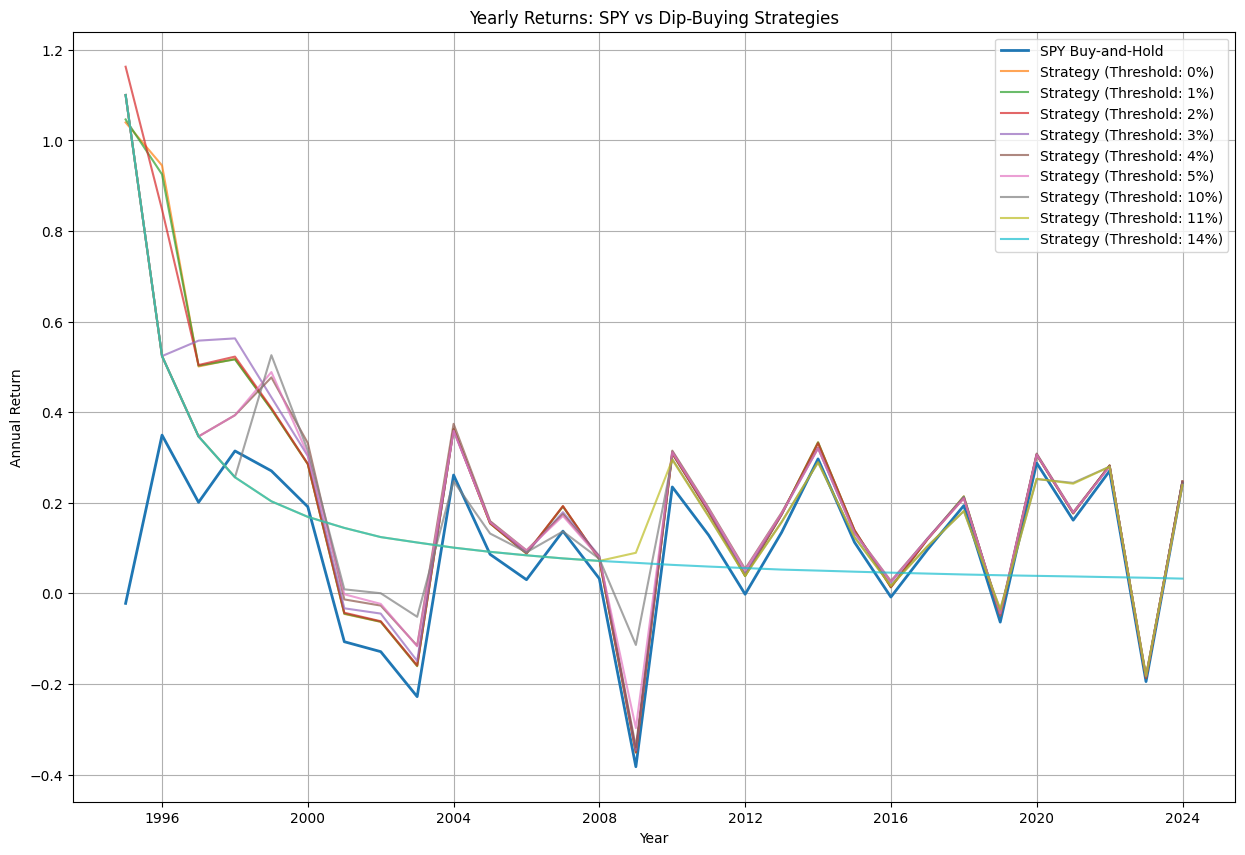

In [97]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_returns(stock_symbol, threshold_percentage, window_size=5):
    stock = yf.download(stock_symbol, start='1993-01-01', end='2024-01-01')
    stock['MA30'] = stock['Close'].rolling(window=7).mean()
    stock['Percent_Diff'] = (stock['Close'] - stock['MA30']) / stock['Close'] * 100
    
    daily_investment = 100
    cash = 0
    shares = 0
    portfolio_values = []
    
    stock['Rolling_Min'] = stock['Close'].rolling(window=window_size, center=True).min()
    
    for i in range(window_size, len(stock) - window_size):
        date = stock.index[i]
        row = stock.iloc[i]
        cash += daily_investment
        
        is_dip = (row['Close'] == row['Rolling_Min']) and \
                 (stock['Close'].iloc[i-1] > row['Close']) and \
                 (stock['Close'].iloc[i+1] > row['Close'])
        
        if is_dip and row['Percent_Diff'] <= -threshold_percentage and cash >= row['Close']:
            shares_to_buy = cash // row['Close']
            cost = shares_to_buy * row['Close']
            cash -= cost
            shares += shares_to_buy
        
        portfolio_value = cash + shares * row['Close']
        portfolio_values.append(portfolio_value)

    portfolio_df = pd.DataFrame({
        'Date': stock.index[window_size:-window_size],
        'Portfolio_Value': portfolio_values
    }).set_index('Date')

    yearly_returns = portfolio_df.resample('YE').last()['Portfolio_Value'].pct_change()
    total_return = (portfolio_df['Portfolio_Value'].iloc[-1] / (daily_investment * len(portfolio_df)) - 1) * 100
    years = (portfolio_df.index[-1] - portfolio_df.index[0]).days / 365.25
    annualized_return = ((1 + total_return/100) ** (1/years) - 1) * 100

    return yearly_returns, total_return, annualized_return

def calculate_spy_performance():
    spy = yf.download("SPY", start='1993-01-01', end='2024-01-01')
    yearly_returns = spy['Close'].resample('YE').last().pct_change()
    total_return = (spy['Close'].iloc[-1] / spy['Close'].iloc[0] - 1) * 100
    years = (spy.index[-1] - spy.index[0]).days / 365.25
    annualized_return = ((1 + total_return/100) ** (1/years) - 1) * 100
    return yearly_returns, total_return, annualized_return

# Calculate SPY buy-and-hold performance
spy_yearly_returns, spy_total_return, spy_annualized_return = calculate_spy_performance()

# Test different threshold percentages
thresholds = [0, 1, 2, 3, 4, 5, 10, 11, 14]
results = []

for threshold in thresholds:
    yearly_returns, total_return, annualized_return = calculate_returns("SPY", threshold)
    results.append({
        'Threshold': threshold,
        'Yearly Returns': yearly_returns,
        'Total Return': total_return,
        'Annualized Return': annualized_return
    })

# Plot yearly returns for all strategies
plt.figure(figsize=(15, 10))
plt.plot(spy_yearly_returns.index, spy_yearly_returns, label='SPY Buy-and-Hold', linewidth=2)

for result in results:
    plt.plot(result['Yearly Returns'].index, result['Yearly Returns'], 
             label=f"Strategy (Threshold: {result['Threshold']}%)", alpha=0.7)

plt.title('Yearly Returns: SPY vs Dip-Buying Strategies')
plt.xlabel('Year')
plt.ylabel('Annual Return')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed
18:44:34 - cmdstanpy - INFO - Chain [1] start processing
18:44:36 - cmdstanpy - INFO - Chain [1] done processing


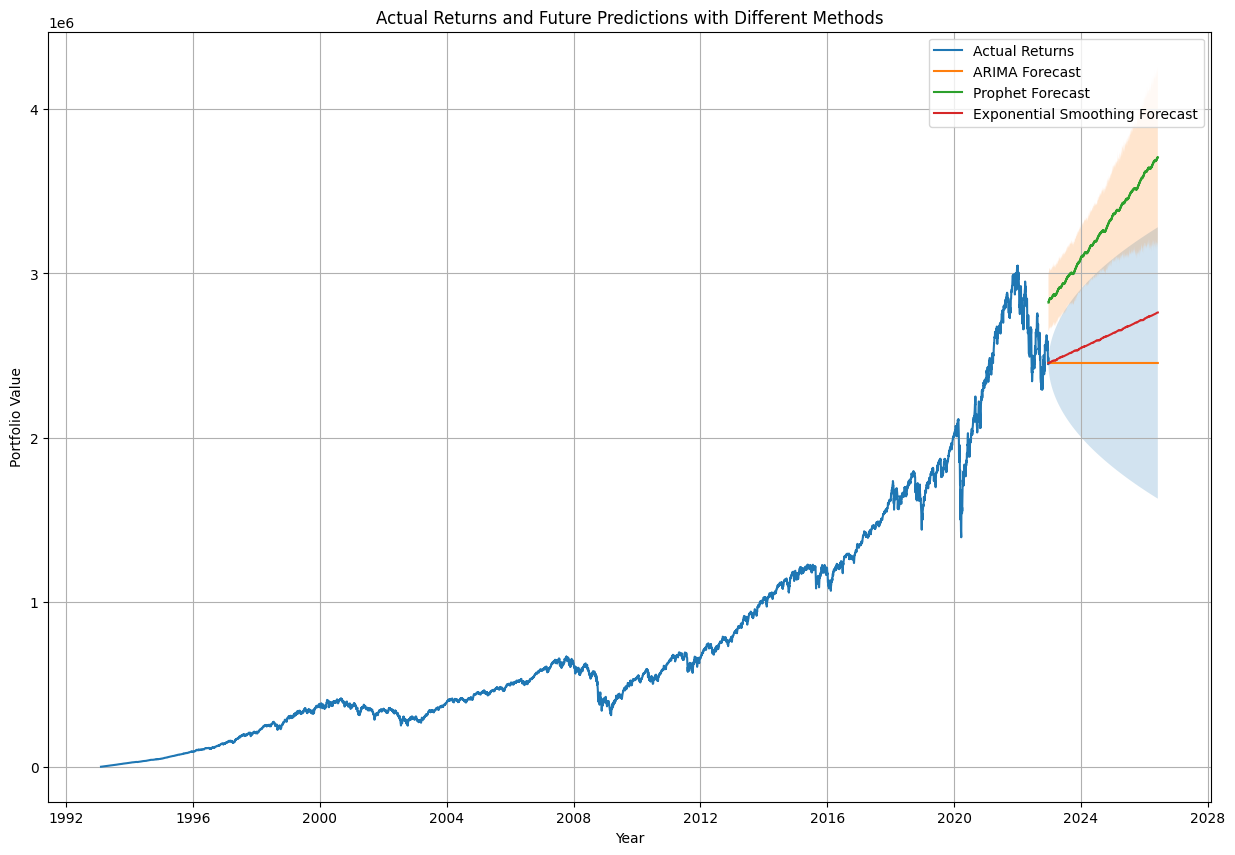

In [101]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

def calculate_returns(stock_symbol, threshold_percentage, window_size=5):
    stock = yf.download(stock_symbol, start='1993-01-01', end='2023-01-01')
    stock['MA30'] = stock['Close'].rolling(window=30).mean()
    stock['Percent_Diff'] = (stock['Close'] - stock['MA30']) / stock['MA30'] * 100
    
    daily_investment = 100
    cash = 0
    shares = 0
    portfolio_values = []
    
    stock['Rolling_Min'] = stock['Close'].rolling(window=window_size, center=True).min()
    
    for i in range(window_size, len(stock) - window_size):
        date = stock.index[i]
        row = stock.iloc[i]
        cash += daily_investment
        
        is_dip = (row['Close'] == row['Rolling_Min']) and \
                 (stock['Close'].iloc[i-1] > row['Close']) and \
                 (stock['Close'].iloc[i+1] > row['Close'])
        
        if is_dip and row['Percent_Diff'] <= -threshold_percentage and cash >= row['Close']:
            shares_to_buy = cash // row['Close']
            cost = shares_to_buy * row['Close']
            cash -= cost
            shares += shares_to_buy
        
        portfolio_value = cash + shares * row['Close']
        portfolio_values.append(portfolio_value)

    portfolio_df = pd.DataFrame({
        'Date': stock.index[window_size:-window_size],
        'Portfolio_Value': portfolio_values
    }).set_index('Date')

    yearly_returns = portfolio_df.resample('Y').last()['Portfolio_Value'].pct_change()
    total_return = (portfolio_df['Portfolio_Value'].iloc[-1] / (daily_investment * len(portfolio_df)) - 1) * 100
    years = (portfolio_df.index[-1] - portfolio_df.index[0]).days / 365.25
    annualized_return = ((1 + total_return/100) ** (1/years) - 1) * 100

    return yearly_returns, total_return, annualized_return, portfolio_df

def predict_arima(data, steps):
    model = ARIMA(data, order=(1,1,1))
    results = model.fit()
    forecast = results.forecast(steps=steps)
    conf_int = results.get_forecast(steps=steps).conf_int()
    return forecast, conf_int

def predict_prophet(data, steps):
    df = pd.DataFrame({'ds': data.index, 'y': data.values})
    model = Prophet(interval_width=0.95)
    model.fit(df)
    future = model.make_future_dataframe(periods=steps)
    forecast = model.predict(future)
    return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']][-steps:]

def predict_exponential_smoothing(data, steps):
    model = ExponentialSmoothing(data, trend='add', seasonal='add', seasonal_periods=252)
    results = model.fit()
    forecast = results.forecast(steps)
    return forecast

# Calculate returns for the best strategy (assuming threshold 0%)
yearly_returns, total_return, annualized_return, portfolio_df = calculate_returns("SPY", 0)

# Prepare data for predictions
data = portfolio_df['Portfolio_Value']
future_steps = 252 * 5  # 5 years of trading days

# ARIMA prediction
arima_forecast, arima_conf = predict_arima(data, future_steps)

# Prophet prediction
prophet_forecast = predict_prophet(data, future_steps)

# Exponential Smoothing prediction
es_forecast = predict_exponential_smoothing(data, future_steps)

# Plotting
plt.figure(figsize=(15, 10))
plt.plot(data.index, data, label='Actual Returns')
future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=future_steps)

plt.plot(future_dates, arima_forecast, label='ARIMA Forecast')
plt.fill_between(future_dates, arima_conf.iloc[:, 0], arima_conf.iloc[:, 1], alpha=0.2)

plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast')
plt.fill_between(prophet_forecast['ds'], prophet_forecast['yhat_lower'], prophet_forecast['yhat_upper'], alpha=0.2)

plt.plot(future_dates, es_forecast, label='Exponential Smoothing Forecast')

plt.title('Actual Returns and Future Predictions with Different Methods')
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed
18:48:53 - cmdstanpy - INFO - Chain [1] start processing
18:48:57 - cmdstanpy - INFO - Chain [1] done processing
18:49:00 - cmdstanpy - INFO - Chain [1] start processing
18:49:04 - cmdstanpy - INFO - Chain [1] done processing
18:49:07 - cmdstanpy - INFO - Chain [1] start processing
18:49:11 - cmdstanpy - INFO - Chain [1] done processing
18:49:14 - cmdstanpy - INFO - Chain [1] start processing
18:49:18 - cmdstanpy - INFO - Chain [1] done processing
18:49:21 - cmdstanpy - INFO - Chain [1] start processing
18:49:25 - cmdstanpy - INFO - Chain [1] done processing
18:49:28 - cmdstanpy - INFO - Chain [1] start processing
18:49:31 - cmdstanpy - INFO - Chain [1] done processing
18:49:34 - cmdstanpy - INFO - Chain [1] start processing
18:49:37 - cmdstanpy - INFO - Chain [1] done processing
18:49:40 - cmdstanpy - INFO - Chain [1] start processing
18:49:43 - cmdstanpy - INFO - Chain [1] done processing
18:49:46 - cmdstanpy - INFO

ARIMA:
  MAE: 16780.00
  MSE: 666942692.26
  RMSE: 25825.23
Prophet:
  MAE: 157211.37
  MSE: 43259031802.46
  RMSE: 207988.06
Exponential Smoothing:
  MAE: 22735.62
  MSE: 23685048224.20
  RMSE: 153899.47


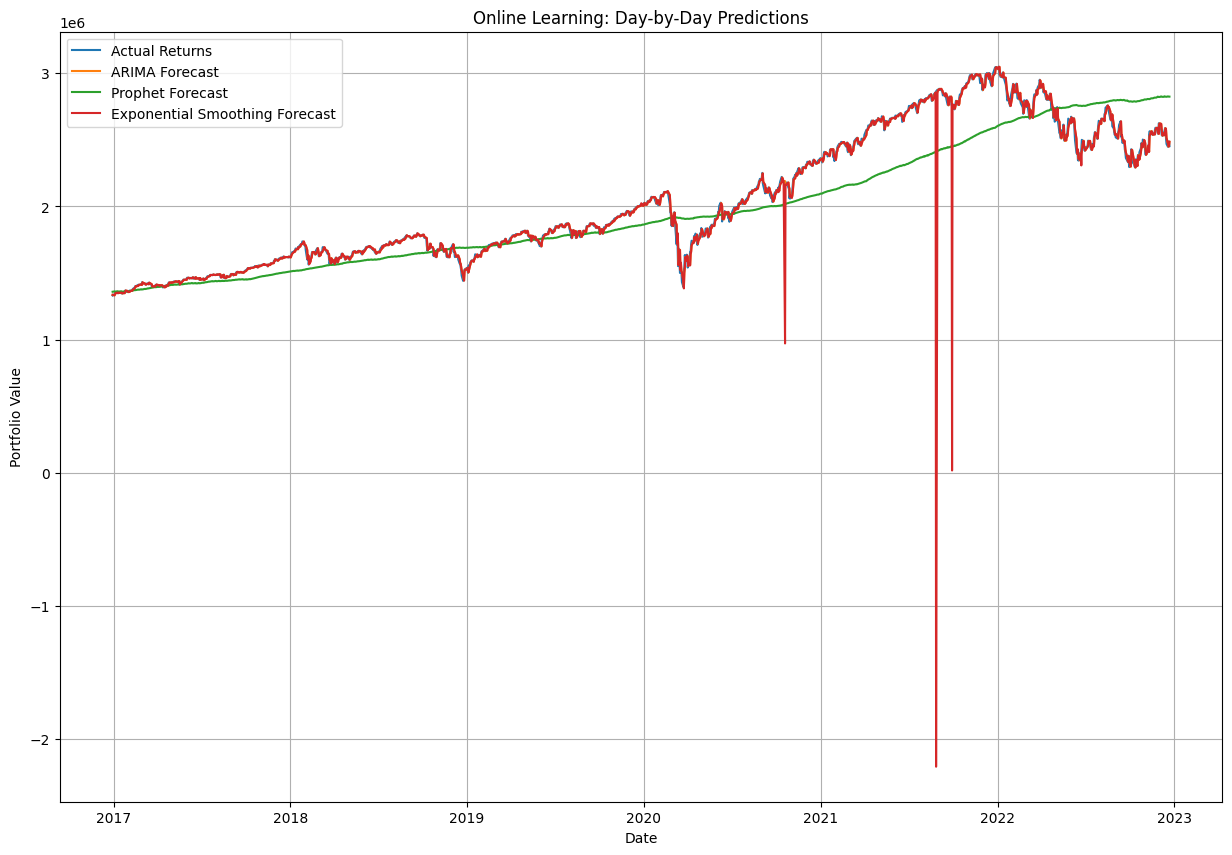

In [104]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

def calculate_returns(stock_symbol, threshold_percentage, window_size=5):
    stock = yf.download(stock_symbol, start='1993-01-01', end='2023-01-01')
    stock['MA30'] = stock['Close'].rolling(window=30).mean()
    stock['Percent_Diff'] = (stock['Close'] - stock['MA30']) / stock['MA30'] * 100
    
    daily_investment = 100
    cash = 0
    shares = 0
    portfolio_values = []
    
    stock['Rolling_Min'] = stock['Close'].rolling(window=window_size, center=True).min()
    
    for i in range(window_size, len(stock) - window_size):
        date = stock.index[i]
        row = stock.iloc[i]
        cash += daily_investment
        
        is_dip = (row['Close'] == row['Rolling_Min']) and \
                 (stock['Close'].iloc[i-1] > row['Close']) and \
                 (stock['Close'].iloc[i+1] > row['Close'])
        
        if is_dip and row['Percent_Diff'] <= -threshold_percentage and cash >= row['Close']:
            shares_to_buy = cash // row['Close']
            cost = shares_to_buy * row['Close']
            cash -= cost
            shares += shares_to_buy
        
        portfolio_value = cash + shares * row['Close']
        portfolio_values.append(portfolio_value)

    portfolio_df = pd.DataFrame({
        'Date': stock.index[window_size:-window_size],
        'Portfolio_Value': portfolio_values
    }).set_index('Date')

    return portfolio_df

def predict_arima(train_data, steps=1):
    model = ARIMA(train_data, order=(1,1,1))
    results = model.fit()
    forecast = results.forecast(steps=steps)
    return forecast.values

def predict_prophet(train_data, steps=1):
    df = pd.DataFrame({'ds': train_data.index, 'y': train_data.values})
    model = Prophet(interval_width=0.95)
    model.fit(df)
    future = model.make_future_dataframe(periods=steps, freq='D')
    forecast = model.predict(future)
    return forecast['yhat'].values[-steps:]

def predict_exponential_smoothing(train_data, steps=1):
    model = ExponentialSmoothing(train_data, trend='add', seasonal='add', seasonal_periods=252)
    results = model.fit()
    forecast = results.forecast(steps)
    return forecast.values

# Calculate returns for the best strategy (assuming threshold 0%)
portfolio_df = calculate_returns("SPY", 0)

# Prepare data for predictions
data = portfolio_df['Portfolio_Value']

# Online learning simulation
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

predictions = {
    'ARIMA': [],
    'Prophet': [],
    'Exponential Smoothing': []
}

for i in range(len(test)):
    train_data = pd.concat([train, test[:i]])
    
    # ARIMA prediction
    arima_pred = predict_arima(train_data)
    predictions['ARIMA'].append(arima_pred[0])
    
    # Prophet prediction
    prophet_pred = predict_prophet(train_data)
    predictions['Prophet'].append(prophet_pred[0])
    
    # Exponential Smoothing prediction
    es_pred = predict_exponential_smoothing(train_data)
    predictions['Exponential Smoothing'].append(es_pred[0])

# Calculate errors
errors = {}
for model, preds in predictions.items():
    mae = mean_absolute_error(test[:len(preds)], preds)
    mse = mean_squared_error(test[:len(preds)], preds)
    rmse = np.sqrt(mse)
    errors[model] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}

# Print errors
for model, metrics in errors.items():
    print(f"{model}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}")

# Plotting
plt.figure(figsize=(15, 10))
plt.plot(test.index, test, label='Actual Returns')
for model, preds in predictions.items():
    plt.plot(test.index[:len(preds)], preds, label=f'{model} Forecast')

plt.title('Online Learning: Day-by-Day Predictions')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True)
plt.show()